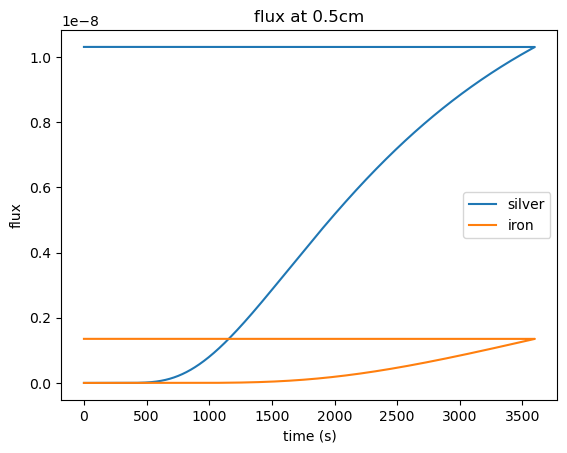

In [24]:
#Question 1: Concentration Question
import numpy
from matplotlib import pyplot as plot

d_ag=14.1*10**-6
d_fe=6.1*10**-6

#Using t=1s and 

n_nodes=101
delta_x=1/(n_nodes-1)
delta_t=1

C=numpy.zeros((3601,101))
C[0,0]=1e-3

#ag
for t in range(3600):
    C[t+1,0]=1e-3
    C[t+1,100]=0
    for i in range(1,100):
        C[t+1,i]=C[t,i]+d_ag*delta_t/delta_x**2*(C[t,i-1]-2*C[t,i]+C[t,i+1])

#flux @ node 50
flux_ag=-d_ag*(C[:,51]-C[:,49])/(2*delta_x)
x=numpy.zeros(3601)
for i in range(3600):
    x[i]=i

#fe
C_fe=numpy.zeros((3601,101))
C_fe[0,0]=1e-3

for t in range(3600):
    C_fe[t+1,0]=1e-3
    C_fe[t+1,100]=0
    for i in range(1,100):
        C_fe[t+1,i]=C_fe[t,i]+d_fe*delta_t/delta_x**2*(C_fe[t,i-1]-2*C_fe[t,i]+C_fe[t,i+1])

flux_fe=-d_fe*(C_fe[:,51]-C_fe[:,49])/(2*delta_x)

plot.plot(x,flux_ag,label='silver')
plot.plot(x,flux_fe,label='iron')
plot.xlabel("time (s)")
plot.ylabel("flux")
plot.title("flux at 0.5cm")
plot.legend()
plot.show()

For the Forward Euler solution to remain stable and avoid divergent oscillations, the time step $\Delta t$ must satisfy the condition:

$$\Delta t \le \frac{2}{|\lambda_{max}|}$$

Where $\lambda_{max}$ is the largest eigenvalue of the matrix. For a 1D diffusion problem using finite differences, the max eigenvalue is defined by the grid spacing and diffusion coefficient:

$$\lambda_{max} \approx -\frac{4D}{\Delta x^2}$$

Substituting this into the stability condition:

$$\Delta t \le \frac{2}{4D/\Delta x^2} \implies \frac{D\Delta t}{\Delta x^2} \le 0.5$$

Application to Parameters:  
Grid Spacing ($\Delta x$): $1.0\text{ cm} / (101 - 1) = 0.01\text{ cm}$  
Time Step ($\Delta t$): $1\text{s}$  
Larger Diffusion Coefficient ($D_{Ag}$): $14.1 \times 10^{-6}\text{ cm}^2/\text{s}$

$$\frac{D\Delta t}{\Delta x^2} = \frac{(14.1 \times 10^{-6})(1)}{(0.01)^2} = 0.141$$

Since $0.141 \le 0.5$, the choice of $\Delta t = 1\text{ s}$ is numerically stable. The other coefficient D is smaller, and would also make the inequality true.

In [26]:
#Question 2: Integration Intro
import numpy
import scipy

x=numpy.array([0,1,2,3,4,5,6,7,8,9,10])
y=numpy.array([63,97,76,31,40,41,89,81,85,14,98])

#a) Riemann

skinny_rectangles=numpy.zeros(11)
delta_x=1

for i in range(11):
    skinny_rectangles[i]=delta_x*y[i]

print("Riemann sum is",sum(skinny_rectangles))

#b) Trap Rule

traps=numpy.zeros(10)

for i in range(10):
    traps[i]=(y[i]+y[i+1])/2*delta_x

print("Trap rule sum is", sum(traps))
#c) Simpson's 1/3

simpson=1/3*(y[0]+4*y[1]+2*y[2]+4*y[3]+2*y[4]+4*y[5]+2*y[6]+4*y[7]+2*y[8]+4*y[9]+y[10])

print("Simpson's 1/3 rule sum is", simpson)

#for i in range(1,10):
#d) SciPy
print("SciPy Trap Rule sum is", scipy.integrate.trapezoid(y,x=x))
print("SciPy Simpson's Rule sum is", scipy.integrate.simpson(y,x=x))

Riemann sum is 715.0
Trap rule sum is 634.5
Simpson's 1/3 rule sum is 599.0
SciPy Trap Rule sum is 634.5
SciPy Simpson's Rule sum is 598.9999999999999


Riemann vals: [2.01987734 1.8127953  1.79384483 1.79196782]
Trap vals: [1.81154401 1.79196196 1.79176149 1.79175949]
Simpson vals: [1.79316979 1.79175968 1.79175947 1.79175947]
Riemann Errors: [2.28117876e-01 2.10358276e-02 2.08535879e-03 2.08353588e-04]
Trap Errors: [1.97845423e-02 2.02494315e-04 2.02545776e-06 2.02546346e-08]
Simpson Errors: [1.41032394e-03 2.06945957e-07 2.08171258e-11 4.44089210e-15]


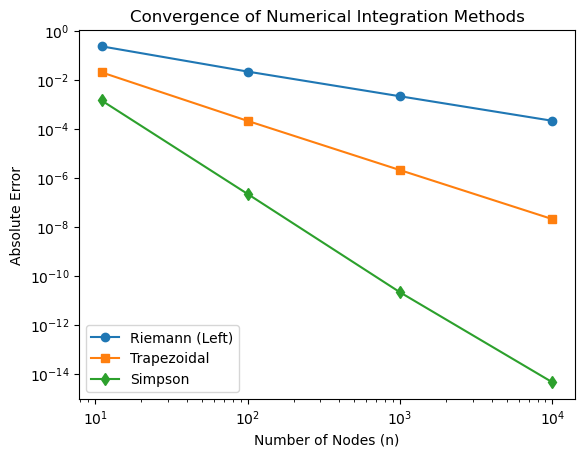

In [26]:
#Question 3: Numerical Integration

import numpy
from matplotlib import pyplot as plot

test_n=numpy.array([11,101,1001,10001])

def f(x):
    return 1/(1+x)

def riemann(n,a,b):
    delta_x=(b-a)/(n-1)
    total=0
    for i in range(n-1):
        x=a+delta_x*i #remember that the x needs to account for shift a!
        total+=f(x)*delta_x
    return total


riemann_vals=numpy.zeros(4)
for i in range(4):
    riemann_vals[i]=riemann(test_n[i],0,5)

print("Riemann vals:",riemann_vals)

def trap(n,a,b):
    delta_x=(b-a)/(n-1)
    total=0
    for i in range(n-1):
        x=a+delta_x*i
        total+=(f(x)+f(x+delta_x))/2*delta_x
    return total

trap_vals=numpy.zeros(4)

for i in range(4):
    trap_vals[i]=trap(test_n[i],0,5)
print("Trap vals:",trap_vals)

def simpson(n,a,b):
    delta_x=(b-a)/(n-1)
    total=0
    for i in numpy.arange(0,n-1,2):
        start_x=a+delta_x*i
        mid_x=a+delta_x*(i+1)
        end_x=a+delta_x*(i+2)
        total+=(delta_x/3)*(f(start_x)+4*f(mid_x)+f(end_x))
    return total

simpson_vals=numpy.zeros(4)

for i in range(4):
    simpson_vals[i]=simpson(test_n[i],0,5)
print("Simpson vals:",simpson_vals)

exact_val = numpy.log(6)
riemann_error = numpy.abs(riemann_vals - exact_val)
trap_error = numpy.abs(trap_vals - exact_val)
simpson_error = numpy.abs(simpson_vals - exact_val)

print("Riemann Errors:", riemann_error)
print("Trap Errors:", trap_error)
print("Simpson Errors:", simpson_error)

plot.loglog(test_n, riemann_error, 'o-', label='Riemann (Left)')
plot.loglog(test_n, trap_error, 's-', label='Trapezoidal')
plot.loglog(test_n, simpson_error, 'd-', label='Simpson')
plot.xlabel('Number of Nodes (n)')
plot.ylabel('Absolute Error')
plot.title('Convergence of Numerical Integration Methods')
plot.legend()
plot.show()

Simpson has the best scaling. It has the smallest absolute error and decreases the fastest as well.

In [1]:
pwd

'/Users/kristenponleithner'